<div style="padding:30px 34px;border-radius:18px;background:#f5f3ef;border:1px solid #e5e1db;color:#25252b;">
<div style="font-size:12px;letter-spacing:2px;color:#73737e;">PROBLAB · A VISUAL TOUR</div>
<h1 style="margin:12px 0;font-size:36px;">Build randomness. Keep the connections.</h1>
<p style="font-size:17px;max-width:760px;line-height:1.6;">Turn distributions into random variables, combine them into models, ask probability questions, and see how uncertainty moves through the graph.</p>
<div style="font-size:13px;color:#73737e;">7 examples · reproducible generators · analytical comparisons · public API</div>
</div>

### Start here

Select the project's **.venv Python kernel**, then choose **Run All**. Install the project with `python -m pip install -e .` from the repository root first if needed; see [README.md](README.md) for the exact commands.

All ProbLab results below use sampling. Curves labeled **analytical** come from explicit formulas or SciPy reference distributions, not from ProbLab's unfinished exact-statistics hooks. Small differences between samples and reference curves are expected.

**Reproducibility:** every experiment gets a fresh seeded generator. Re-running a cell repeats that experiment in the same environment. Changing sample counts or library versions can change the results.

In [1]:
%matplotlib inline
import sys
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import sympy as sp
from scipy import stats
from IPython.display import display, HTML

from problab import (
    RandomVariable, NormalDistribution, BinomialDistribution,
    PoissonDistribution, CategoricalDistribution, P, Mode,
    HomogeneousNumericValueSet,
)
from problab.functions import exp

COLORS = {"blue": "#5878cf", "purple": "#9670c6", "teal": "#34988f",
          "orange": "#d78c48", "ink": "#30313b", "muted": "#777985"}
plt.rcParams.update({
    "figure.figsize": (12, 4.5), "figure.dpi": 110,
    "figure.facecolor": "#faf9f6", "axes.facecolor": "#faf9f6",
    "axes.edgecolor": "#dcdde2", "axes.labelcolor": COLORS["ink"],
    "text.color": COLORS["ink"], "xtick.color": COLORS["muted"],
    "ytick.color": COLORS["muted"], "font.family": "DejaVu Sans",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titleweight": "bold", "axes.titlesize": 13,
    "axes.grid": True, "grid.color": "#e4e4e9", "grid.alpha": 0.65,
    "axes.axisbelow": True, "legend.frameon": False,
})
SAMPLES = 30_000

def rng(seed):
    return np.random.default_rng(seed)

def show_metrics(items):
    cards = "".join(
        f'<div style="flex:1;min-width:180px;padding:16px 20px;border:1px solid #e5e1db;'
        f'border-radius:12px;background:#f5f3ef;"><div style="color:#73737e;font-size:12px;">'
        f'{label}</div><div style="font-size:23px;color:#30313b;margin-top:5px;">{value}</div></div>'
        for label, value in items
    )
    display(HTML(f'<div style="display:flex;gap:12px;flex-wrap:wrap;margin:14px 0;">{cards}</div>'))

def draw_dependencies(variable, title):
    # NodeGraph exposes the underlying NetworkX graph through its public API.
    # ProbLab edges point to dependencies; reverse them here to show information flow.
    graph = variable.dependency_graph.nx_graph.reverse(copy=True)
    positions = {}
    for layer, nodes in enumerate(nx.topological_generations(graph)):
        ordered = sorted(nodes, key=lambda node: node.name)
        for row, node in enumerate(ordered):
            positions[node] = (layer, row - (len(ordered) - 1) / 2)
    fig, ax = plt.subplots(figsize=(12, 4))
    node_colors = [
        COLORS["teal"] if graph.in_degree(node) == 0 else COLORS["blue"]
        for node in graph
    ]
    nx.draw_networkx_nodes(graph, positions, node_color=node_colors,
                          node_size=1600, edgecolors="#faf9f6", linewidths=2, ax=ax)
    nx.draw_networkx_edges(graph, positions, edge_color="#a8aabc",
                          arrowsize=17, node_size=1600, connectionstyle="arc3,rad=0.03", ax=ax)
    labels = {node: node.name if len(node.name) <= 24 else node.name[:21] + "..."
              for node in graph}
    label_positions = {node: (x, y - 0.15) for node, (x, y) in positions.items()}
    nx.draw_networkx_labels(graph, label_positions, labels=labels, font_size=9,
                           font_color=COLORS["ink"],
                           bbox={"facecolor": "#faf9f6", "edgecolor": "none", "pad": 3}, ax=ax)
    ax.set_title(title, loc="left")
    ax.margins(x=0.15, y=0.25)
    y_positions = [y for x, y in positions.values()]
    ax.set_ylim(min(y_positions) - 0.45, max(y_positions) + 0.35)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

print(f"Python {sys.version.split()[0]} · NumPy {np.__version__}")

Python 3.13.5 · NumPy 2.4.6


## 01 · Dice become algebra

Two **different random variables** represent two independent dice. Their sum is a new random variable; comparisons such as `total >= 10` create events that `P()` can evaluate.

The analytical distribution below is the convolution of two uniform six-sided dice.

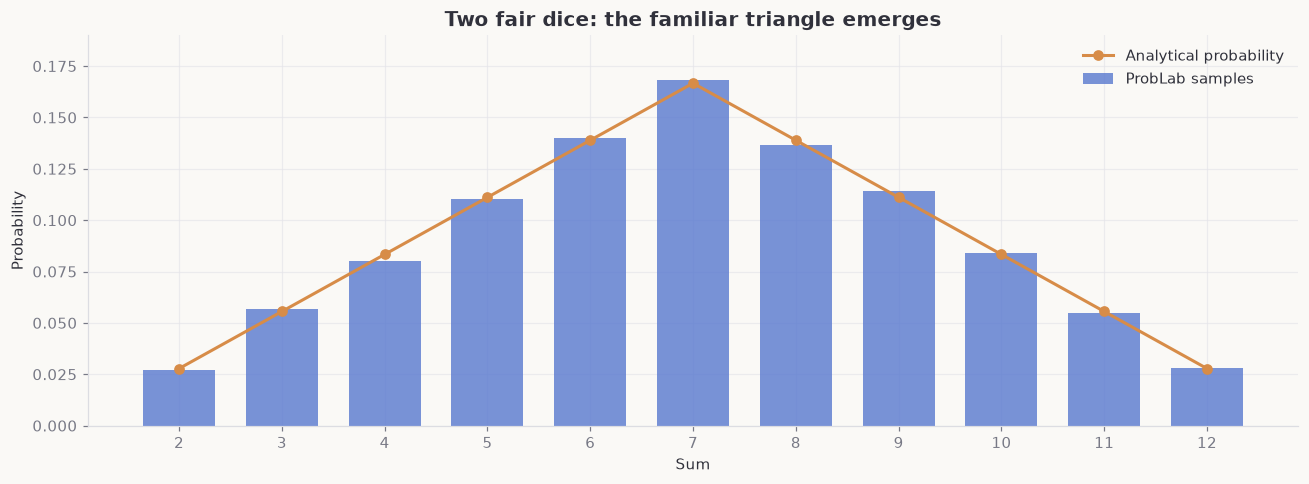

In [2]:
die_distribution = CategoricalDistribution(range(1, 7), [1 / 6] * 6)
die_a = RandomVariable(die_distribution, name="Die A")
die_b = RandomVariable(die_distribution, name="Die B")
total = die_a + die_b

rolls = total.sample(num_samples=SAMPLES, rng=rng(101), validate=True)
sums = np.arange(2, 13)
observed = np.array([np.mean(rolls == value) for value in sums])
analytical = np.convolve(np.full(6, 1 / 6), np.full(6, 1 / 6))
high_roll = P(total >= 10, num_samples=SAMPLES, rng=rng(102), validate=True)
high_roll_ci = high_roll.confidence_interval(alpha=0.05)

fig, ax = plt.subplots()
ax.bar(sums, observed, width=0.7, color=COLORS["blue"], alpha=0.8, label="ProbLab samples")
ax.plot(sums, analytical, "o-", color=COLORS["orange"], linewidth=2, label="Analytical probability")
ax.set(title="Two fair dice: the familiar triangle emerges", xlabel="Sum", ylabel="Probability",
       xticks=sums, ylim=(0, 0.19))
ax.legend()
plt.tight_layout()
plt.show()

show_metrics([
    ("Estimated P(sum ≥ 10)", f"{high_roll.value:.3%}"),
    ("Analytical P(sum ≥ 10)", f"{6 / 36:.3%}"),
    ("95% confidence interval", f"[{high_roll_ci.lower:.3%}, {high_roll_ci.upper:.3%}]"),
])

## 02 · The same variable means the same realization

`X - X` uses the **same underlying draw** twice. It is always zero. `X - independent_X` uses two independent draws and has a wider distribution.

Sampling separate expressions in separate calls does not create aligned joint samples. Build a combined expression when the relationships between variables matter.

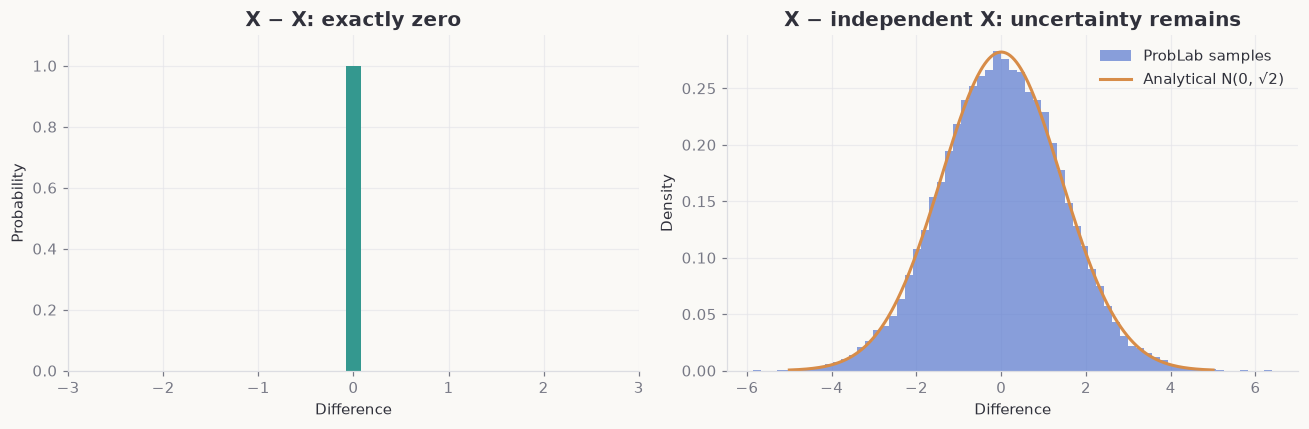

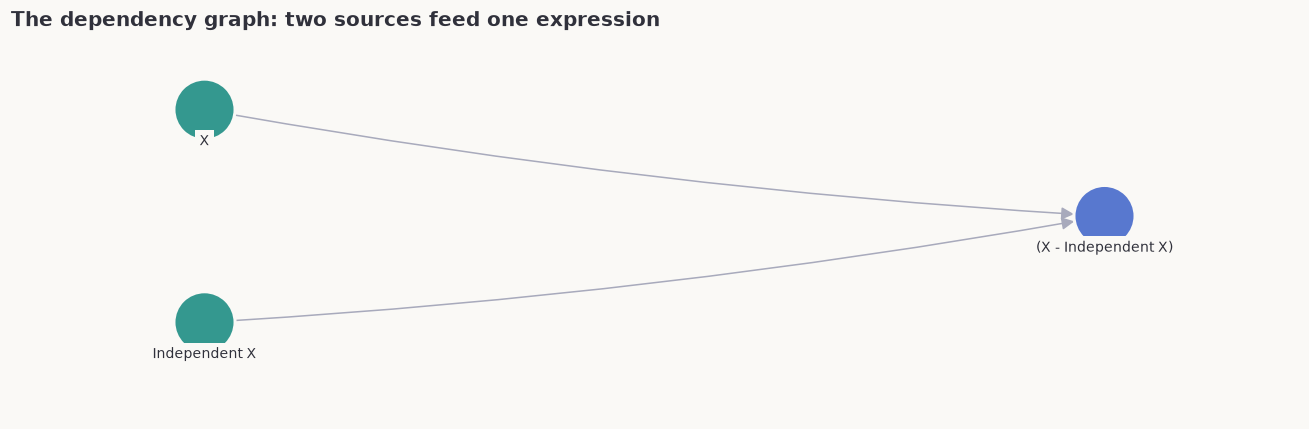

In [3]:
X = RandomVariable(NormalDistribution(mean=0, std=1), name="X")
independent_X = RandomVariable(NormalDistribution(mean=0, std=1), name="Independent X")
shared_difference = X - X
independent_difference = X - independent_X

shared_samples = shared_difference.sample(num_samples=SAMPLES, rng=rng(201), validate=True)
independent_samples = independent_difference.sample(num_samples=SAMPLES, rng=rng(202), validate=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar([0], [1], width=0.15, color=COLORS["teal"])
axes[0].set(title="X − X: exactly zero", xlabel="Difference", ylabel="Probability",
            xlim=(-3, 3), ylim=(0, 1.1))
grid = np.linspace(-5, 5, 400)
axes[1].hist(independent_samples, bins=65, density=True, color=COLORS["blue"], alpha=0.7,
             label="ProbLab samples")
axes[1].plot(grid, stats.norm.pdf(grid, scale=np.sqrt(2)), color=COLORS["orange"],
             linewidth=2, label="Analytical N(0, √2)")
axes[1].set(title="X − independent X: uncertainty remains", xlabel="Difference", ylabel="Density")
axes[1].legend()
plt.tight_layout()
plt.show()

show_metrics([
    ("Nonzero samples of X − X", str(np.count_nonzero(shared_samples))),
    ("Std of independent difference", f"{np.std(independent_samples):.3f}"),
    ("Analytical standard deviation", f"{np.sqrt(2):.3f}"),
])
draw_dependencies(independent_difference, "The dependency graph: two sources feed one expression")

## 03 · A distribution can have a random parameter

Choose a latent mean from `[-2.5, 2.5]`, then draw a Normal variable around that mean. The result is a **Gaussian mixture**: one model with two distinct clusters.

The constructor receives the actual random variable as its mean parameter. ProbLab evaluates that parameter in the same realization as the Normal draw.

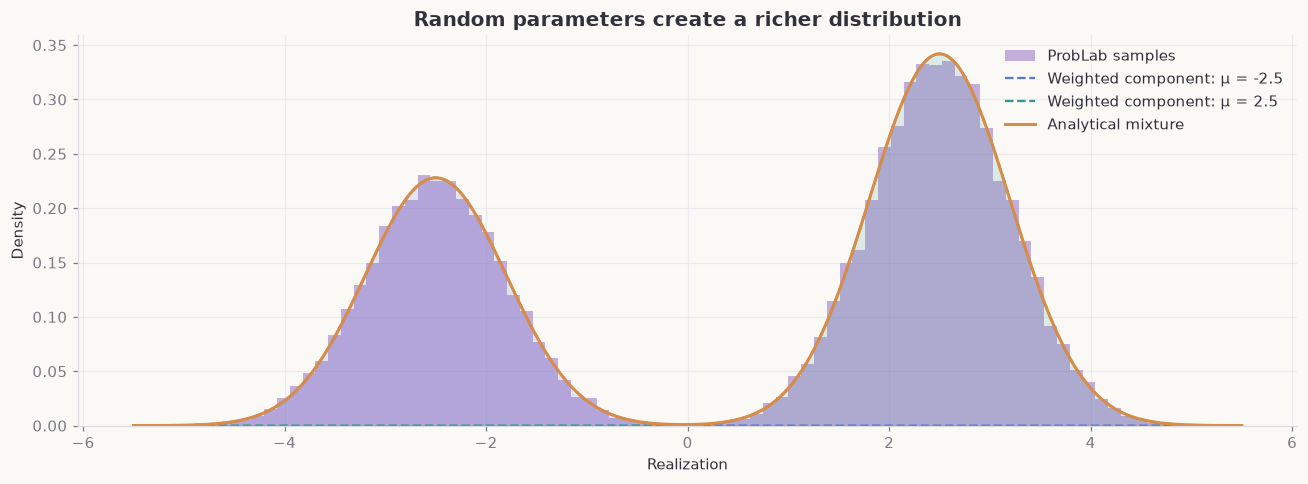

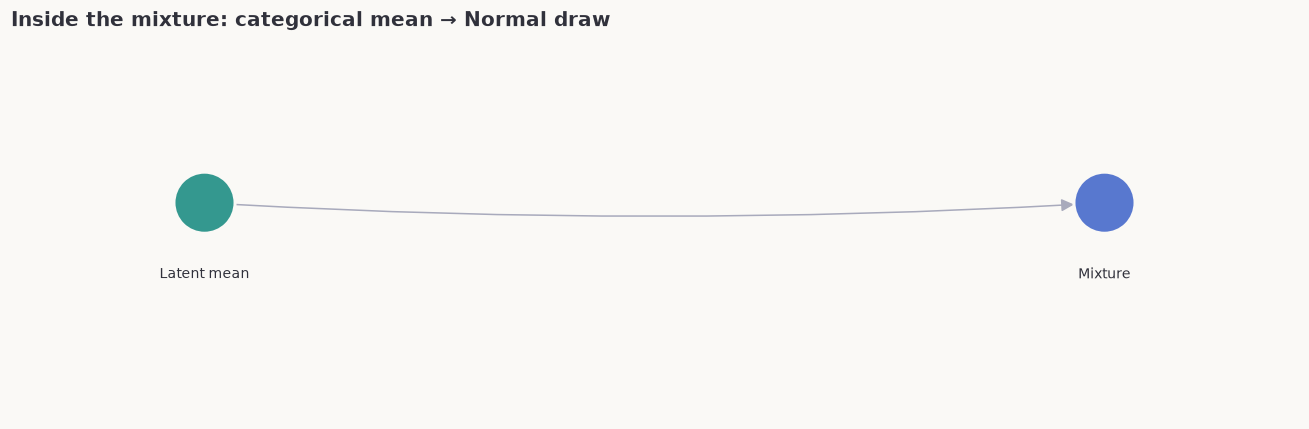

In [4]:
centers = (-2.5, 2.5)
weights = (0.4, 0.6)
latent_mean = RandomVariable(CategoricalDistribution(centers, weights), name="Latent mean")
mixture_distribution = NormalDistribution(mean=latent_mean, std=0.7)
mixture = RandomVariable(mixture_distribution, name="Mixture")
mixture_samples = mixture.sample(num_samples=SAMPLES, rng=rng(301), validate=True)
grid = np.linspace(-5.5, 5.5, 500)
components = [weight * stats.norm.pdf(grid, loc=center, scale=0.7)
              for center, weight in zip(centers, weights)]

fig, ax = plt.subplots()
ax.hist(mixture_samples, bins=80, density=True, color=COLORS["purple"], alpha=0.55,
        label="ProbLab samples")
for density, color, center in zip(components, (COLORS["blue"], COLORS["teal"]), centers):
    ax.fill_between(grid, density, color=color, alpha=0.15)
    ax.plot(grid, density, color=color, linestyle="--", label=f"Weighted component: μ = {center}")
ax.plot(grid, sum(components), color=COLORS["orange"], linewidth=2, label="Analytical mixture")
ax.set(title="Random parameters create a richer distribution", xlabel="Realization", ylabel="Density")
ax.legend()
plt.tight_layout()
plt.show()

show_metrics([
    ("Parameters preserve the input object", str(mixture_distribution.parameters[0] is latent_mean)),
    ("Sample mean", f"{np.mean(mixture_samples):.3f}"),
    ("Analytical mean", f"{np.dot(centers, weights):.3f}"),
])
draw_dependencies(mixture, "Inside the mixture: categorical mean → Normal draw")

## 04 · Random rates explain bursty counts

Imagine a service with **quiet** and **busy** periods. Its request rate is 3 or 12, with probabilities 75% and 25%. Conditional on that rate, the count is Poisson.

A fixed-rate Poisson with the same mean is a different model: random rates add variation. Here
$\operatorname{Var}(N)=\mathbb{E}[\Lambda]+\operatorname{Var}(\Lambda)$.

The Binomial panel shows the same idea for an uncertain success probability.

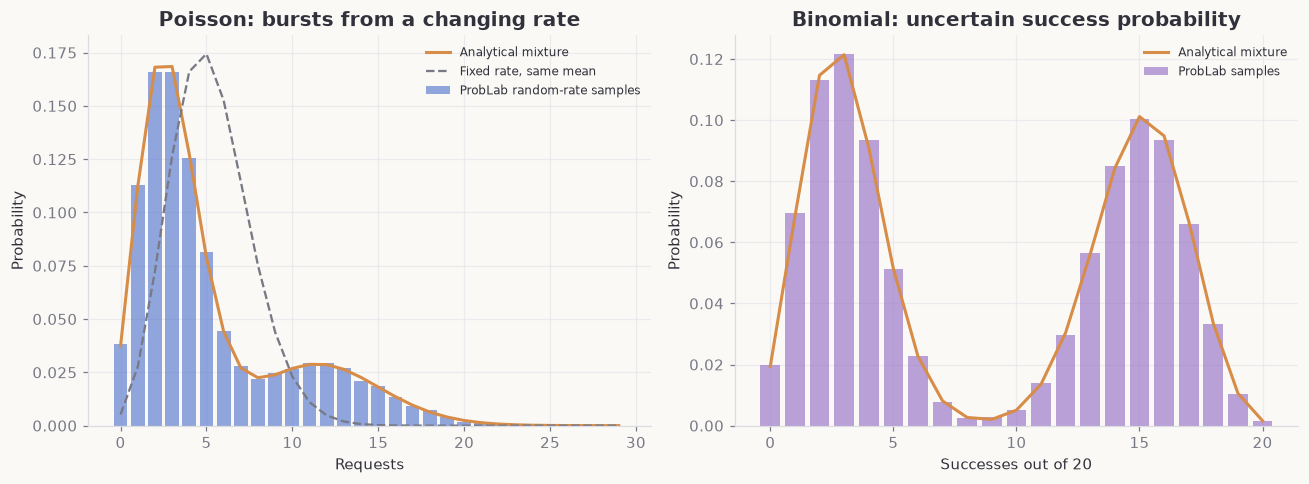

In [5]:
rates = (3, 12)
rate_weights = (0.75, 0.25)
rate = RandomVariable(CategoricalDistribution(rates, rate_weights), name="Request rate")
counts = RandomVariable(PoissonDistribution(mu=rate), name="Requests")
count_samples = counts.sample(num_samples=SAMPLES, rng=rng(401), validate=True)
mean_rate = float(np.dot(rates, rate_weights))
variance_rate = sum(weight * (value - mean_rate) ** 2 for value, weight in zip(rates, rate_weights))
count_grid = np.arange(0, 30)
mixture_pmf = sum(weight * stats.poisson.pmf(count_grid, mu=value)
                  for value, weight in zip(rates, rate_weights))

success_probability = RandomVariable(
    CategoricalDistribution((0.15, 0.75), (0.5, 0.5)), name="Success probability"
)
successes = RandomVariable(BinomialDistribution(n=20, p=success_probability), name="Successes")
success_samples = successes.sample(num_samples=SAMPLES, rng=rng(402), validate=True)
success_grid = np.arange(21)
binomial_mixture = 0.5 * stats.binom.pmf(success_grid, 20, 0.15) + 0.5 * stats.binom.pmf(success_grid, 20, 0.75)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(count_grid, [np.mean(count_samples == k) for k in count_grid],
            color=COLORS["blue"], alpha=0.65, label="ProbLab random-rate samples")
axes[0].plot(count_grid, mixture_pmf, color=COLORS["orange"], linewidth=2, label="Analytical mixture")
axes[0].plot(count_grid, stats.poisson.pmf(count_grid, mean_rate), "--", color=COLORS["muted"],
             label="Fixed rate, same mean")
axes[0].set(title="Poisson: bursts from a changing rate", xlabel="Requests", ylabel="Probability")
axes[0].legend(fontsize=8)
axes[1].bar(success_grid, [np.mean(success_samples == k) for k in success_grid],
            color=COLORS["purple"], alpha=0.65, label="ProbLab samples")
axes[1].plot(success_grid, binomial_mixture, color=COLORS["orange"], linewidth=2,
             label="Analytical mixture")
axes[1].set(title="Binomial: uncertain success probability", xlabel="Successes out of 20", ylabel="Probability")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

show_metrics([
    ("Mean request count", f"{np.mean(count_samples):.2f} (analytical {mean_rate:.2f})"),
    ("Request-count variance", f"{np.var(count_samples):.2f} (analytical {mean_rate + variance_rate:.2f})"),
    ("Fixed-rate Poisson variance", f"{mean_rate:.2f}"),
])

## 05 · Turn an observation into a probability question

An alarm fires when at least 10 requests arrive. How likely is it that we were in a busy period **given that alarm**?

`P(busy, given=alarm)` samples the shared model and keeps the realizations in which the alarm occurred. It divides the busy-and-alarm count by the alarm count.

The analytical reference uses Bayes' rule:
$P(\text{busy}\mid\text{alarm})=\frac{0.25\,P(\operatorname{Poisson}(12)\geq10)}{0.75\,P(\operatorname{Poisson}(3)\geq10)+0.25\,P(\operatorname{Poisson}(12)\geq10)}$.

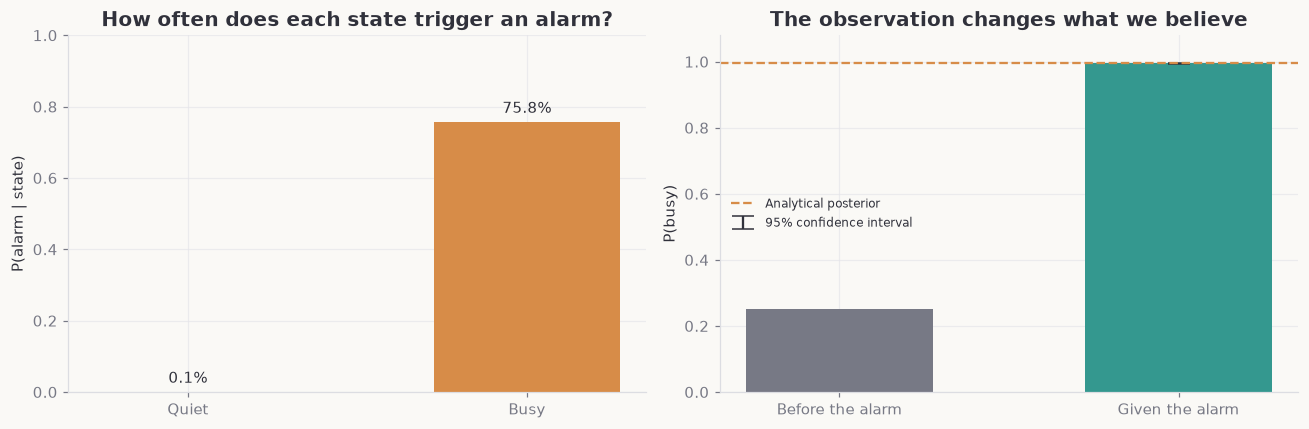

In [6]:
busy = rate == 12
alarm = counts >= 10
posterior = P(busy, given=alarm, num_samples=60_000, rng=rng(501), validate=True)
posterior_ci = posterior.confidence_interval(alpha=0.05)
alarm_likelihoods = stats.poisson.sf(9, np.asarray(rates))
analytical_posterior = rate_weights[1] * alarm_likelihoods[1] / np.dot(rate_weights, alarm_likelihoods)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(["Quiet", "Busy"], alarm_likelihoods, color=[COLORS["blue"], COLORS["orange"]], width=0.55)
axes[0].set(title="How often does each state trigger an alarm?", ylabel="P(alarm | state)", ylim=(0, 1))
for index, value in enumerate(alarm_likelihoods):
    axes[0].text(index, value + 0.025, f"{value:.1%}", ha="center")
axes[1].bar(["Before the alarm", "Given the alarm"], [0.25, posterior.value],
            color=[COLORS["muted"], COLORS["teal"]], width=0.55)
axes[1].errorbar(1, posterior.value,
                 yerr=[[posterior.value - posterior_ci.lower], [posterior_ci.upper - posterior.value]],
                 fmt="none", color=COLORS["ink"], capsize=7, label="95% confidence interval")
axes[1].axhline(analytical_posterior, color=COLORS["orange"], linestyle="--", label="Analytical posterior")
axes[1].set(title="The observation changes what we believe", ylabel="P(busy)", ylim=(0, 1.08))
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

show_metrics([
    ("Estimated P(busy | alarm)", f"{posterior.value:.2%}"),
    ("Analytical posterior", f"{analytical_posterior:.2%}"),
    ("Alarm realizations used", f"{posterior.num_conditioned_samples:,} / {posterior.num_unconditioned_samples:,}"),
])

## 06 · Transform the whole distribution

`exp(0.6 * X)` turns a standard Normal variable into a **lognormal** variable. A custom `apply()` can map the same kind of input into a bounded response.

With `vectorized=True`, the custom function receives an entire sample array. Here we explicitly declare its output support so ProbLab can validate the realizations.

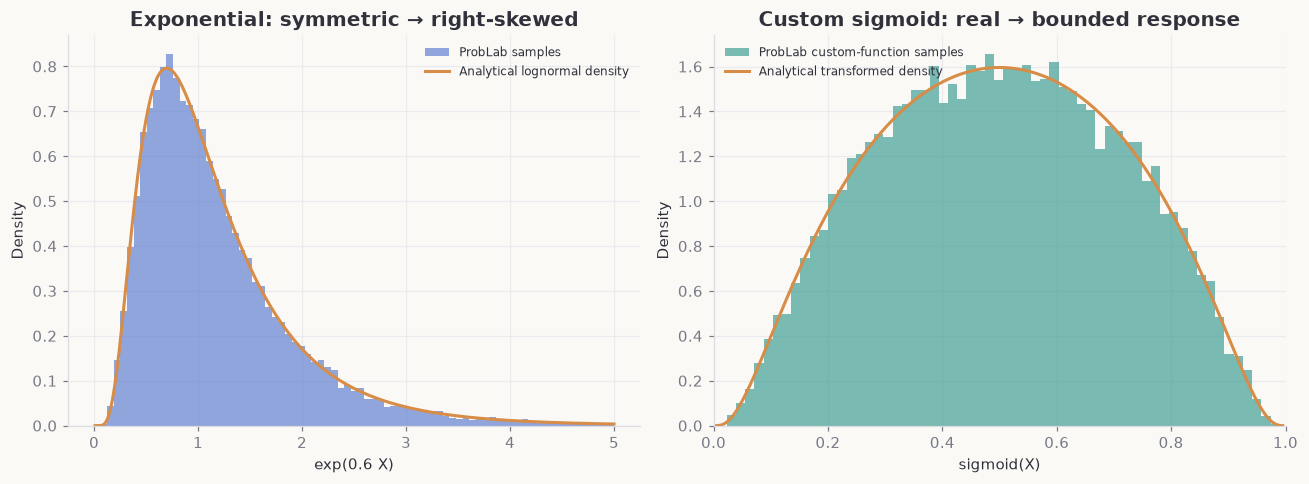

In [7]:
positive = exp(0.6 * X)
unit_interval = HomogeneousNumericValueSet(
    sympy_set=sp.Interval(0, 1), dtype_types=(np.floating,)
)
response = X.apply(
    lambda values: 1 / (1 + np.exp(-values)),
    mathematical_value_set=HomogeneousNumericValueSet(
        sympy_set=sp.Interval.open(0, 1), dtype_types=(np.floating,)
    ),
    realization_value_set=unit_interval,
    function_name="sigmoid",
    vectorized=True,
)
positive_samples = positive.sample(num_samples=SAMPLES, rng=rng(601), validate=True)
response_samples = response.sample(num_samples=SAMPLES, rng=rng(602), validate=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
positive_grid = np.linspace(0.01, 5, 500)
positive_bins = np.linspace(0, 5, 80)
# Keep the full sample count in the density denominator, including the tail outside the plot.
positive_weights = np.full(positive_samples.size, 1 / (positive_samples.size * np.diff(positive_bins)[0]))
axes[0].hist(positive_samples, bins=positive_bins, weights=positive_weights,
             color=COLORS["blue"], alpha=0.65, label="ProbLab samples")
axes[0].plot(positive_grid, stats.lognorm.pdf(positive_grid, s=0.6),
             color=COLORS["orange"], linewidth=2, label="Analytical lognormal density")
axes[0].set(title="Exponential: symmetric → right-skewed", xlabel="exp(0.6 X)", ylabel="Density")
axes[0].legend(fontsize=8)
response_grid = np.linspace(0.005, 0.995, 500)
logit = np.log(response_grid / (1 - response_grid))
response_density = stats.norm.pdf(logit) / (response_grid * (1 - response_grid))
axes[1].hist(response_samples, bins=60, density=True, color=COLORS["teal"], alpha=0.65,
             label="ProbLab custom-function samples")
axes[1].plot(response_grid, response_density, color=COLORS["orange"], linewidth=2,
             label="Analytical transformed density")
axes[1].set(title="Custom sigmoid: real → bounded response", xlabel="sigmoid(X)", ylabel="Density",
            xlim=(0, 1))
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

show_metrics([
    ("Lognormal sample mean", f"{np.mean(positive_samples):.3f}"),
    ("Analytical lognormal mean", f"{np.exp(0.6 ** 2 / 2):.3f}"),
    ("Sampled sigmoid range", f"[{response_samples.min():.3f}, {response_samples.max():.3f}]"),
])

## 07 · Two different kinds of interval

A **probability interval** describes where realizations lie: for a standard Normal variable, the central 95% interval is roughly [−1.96, 1.96].

A **confidence interval for the median** describes uncertainty about an estimated statistic. Its width shrinks as we collect more samples. These intervals answer different questions.

The final plot shows how the uncertainty in a sampled event probability typically shrinks with larger sample sizes. Individual estimates need not move monotonically toward the analytical value.

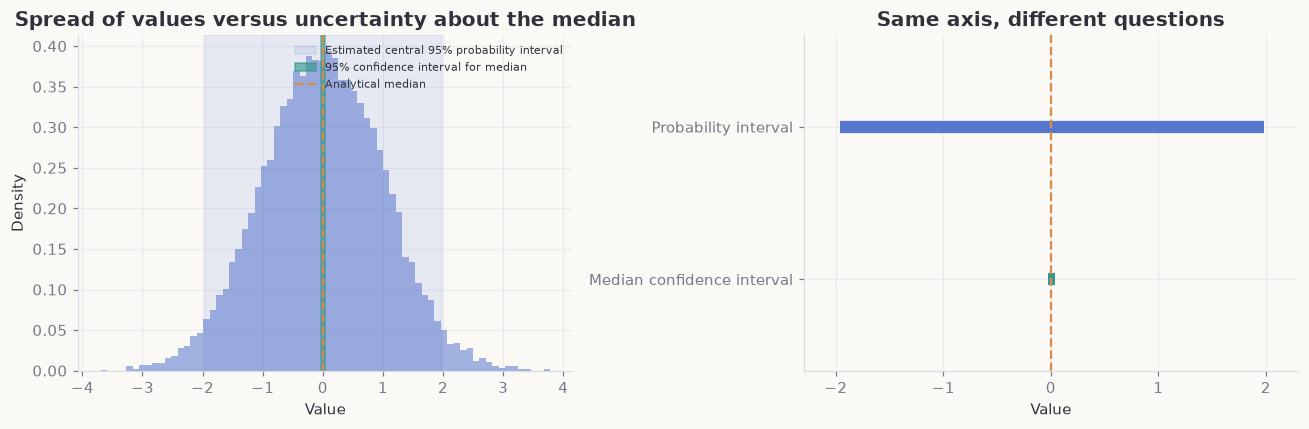

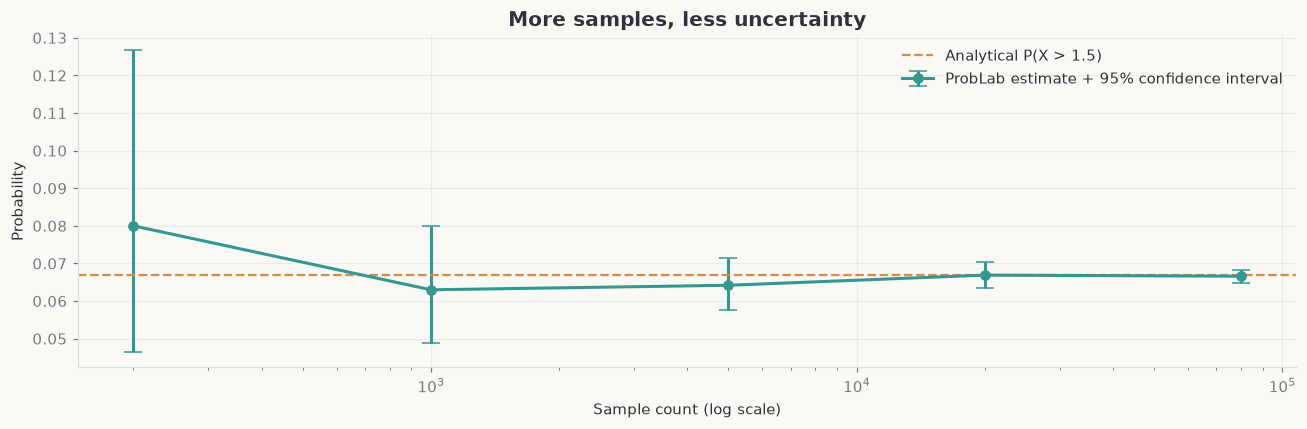

In [8]:
population_interval = X.interval(alpha=0.05, num_samples=20_000, rng=rng(701))
median_interval = X.quantile_confidence_interval(q=0.5, alpha=0.05, num_samples=5_000, rng=rng(702))
reference_samples = X.sample(num_samples=20_000, rng=rng(703))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(reference_samples, bins=70, density=True, color=COLORS["blue"], alpha=0.55)
axes[0].axvspan(population_interval.lower, population_interval.upper,
                color=COLORS["blue"], alpha=0.12, label="Estimated central 95% probability interval")
axes[0].axvspan(median_interval.lower, median_interval.upper,
                color=COLORS["teal"], alpha=0.65, label="95% confidence interval for median")
axes[0].axvline(0, color=COLORS["orange"], linestyle="--", label="Analytical median")
axes[0].set(title="Spread of values versus uncertainty about the median", xlabel="Value", ylabel="Density")
axes[0].legend(fontsize=7)
axes[1].hlines(1, population_interval.lower, population_interval.upper,
               color=COLORS["blue"], linewidth=8)
axes[1].hlines(0, median_interval.lower, median_interval.upper,
               color=COLORS["teal"], linewidth=8)
axes[1].axvline(0, color=COLORS["orange"], linestyle="--")
axes[1].set(title="Same axis, different questions", xlabel="Value",
            yticks=[0, 1], yticklabels=["Median confidence interval", "Probability interval"],
            ylim=(-0.6, 1.6), xlim=(-2.3, 2.3))
plt.tight_layout()
plt.show()

sample_sizes = np.array([200, 1_000, 5_000, 20_000, 80_000])
tail_results = [P(X > 1.5, num_samples=int(n), rng=rng(710 + index))
                for index, n in enumerate(sample_sizes)]
tail_intervals = [result.confidence_interval(alpha=0.05) for result in tail_results]
estimates = np.array([result.value for result in tail_results])
errors = np.array([
    estimates - np.array([interval.lower for interval in tail_intervals]),
    np.array([interval.upper for interval in tail_intervals]) - estimates,
])
fig, ax = plt.subplots(figsize=(12, 4))
ax.errorbar(sample_sizes, estimates, yerr=errors, fmt="o-", color=COLORS["teal"],
             capsize=6, linewidth=2, label="ProbLab estimate + 95% confidence interval")
ax.axhline(stats.norm.sf(1.5), color=COLORS["orange"], linestyle="--", label="Analytical P(X > 1.5)")
ax.set(xscale="log", title="More samples, less uncertainty", xlabel="Sample count (log scale)", ylabel="Probability")
ax.legend()
plt.tight_layout()
plt.show()

# Distribution-level numerical methods use an explicit Monte Carlo mode.
normal = NormalDistribution(mean=0, std=1)
show_metrics([
    ("Monte Carlo mean", f"{normal.mean(mode=Mode.MONTE_CARLO, num_samples=20_000, rng=rng(720)):.3f}"),
    ("Monte Carlo CDF at 0", f"{normal.cdf(0, mode=Mode.MONTE_CARLO, num_samples=20_000, rng=rng(721)):.3f}"),
    ("Monte Carlo 95th percentile", f"{normal.ppf(0.95, mode=Mode.MONTE_CARLO, num_samples=20_000, rng=rng(722)):.3f}"),
])

## Keep exploring

Change one assumption and rerun its section:

- **Dice:** make one die biased and watch the sum distribution change.
- **Mixtures:** move the cluster centers or change their weights.
- **Counts:** bring the two rates closer together and watch the overdispersion shrink.
- **Conditioning:** increase the alarm threshold and compare the posterior probability with the number of retained samples.
- **Transforms:** change `0.6` in the exponential model and update the analytical curve's `s` parameter.
- **Intervals:** increase the sample count and compare confidence-interval widths.

### What this tour demonstrates

| Feature | Example |
|---|---|
| Categorical, Normal, Poisson, and Binomial distributions | Dice, Gaussian mixture, changing rates, uncertain success probability |
| Arithmetic and shared dependencies | Dice sums and differences |
| Public dependency graphs | Two sources and a hierarchical model |
| Random distribution parameters | Random Normal mean, Poisson rate, and Binomial success probability |
| Events and conditional probability | High dice sums and inference from an alarm |
| Predefined and custom transformations | Exponential and sigmoid |
| Realization validation | Sampling with `validate=True` |
| Probability and quantile confidence intervals | Monte Carlo estimates and the median |
| Distribution-level Monte Carlo statistics | Mean, CDF, and PPF |

The sample estimates and saved plots illustrate behavior; they are not a replacement for the test suite.